# 07 · A Tool-Calling Agent, From Scratch

A language model can't reliably multiply `4877 × 619` in its head — but it can *call a calculator*. This notebook builds a **ReAct-style agent** with no framework, then measures, honestly, what tools buy a small model.

1. **The loop** — `task → model → JSON action → run tool → observation → repeat → final_answer`, in plain Python.
2. **A safe tool registry** — an `ast`-based calculator (never `eval`), with every failure turned into an observation the model can recover from.
3. **Failure modes** — a 0.5B model loops, mis-plans, and emits malformed JSON; we watch all three and engineer around them.
4. **The payoff** — tools make arithmetic *exact* (they fix the very slip chain-of-thought made in Notebook 06), but a rigid protocol is a tax a small model pays. We quantify both.

Reusable code: `llmlab/agent/{tools,parsing,prompts,loop}.py`; tests: `tests/test_agent.py` (the whole loop is tested with a scripted fake model). The scratchpad here is the agent's **working memory** — Notebook 08 makes memory persistent.

In [ ]:
import sys
from pathlib import Path

LLM_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(LLM_DIR) not in sys.path:
    sys.path.insert(0, str(LLM_DIR))

import json
import warnings
warnings.filterwarnings("ignore")
import transformers
transformers.logging.set_verbosity_error()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from llmlab import config
from llmlab.models.local_model import LocalModel, SamplingConfig
from llmlab.agent.tools import make_default_registry, calculate
from llmlab.agent.parsing import extract_json
from llmlab.agent.prompts import build_system_prompt
from llmlab.agent.loop import Agent, evaluate_agent
from llmlab.evals.tasks import GSM_TASKS, HARD_ARITHMETIC_TASKS
from llmlab.evals.prompts import cot_messages
from llmlab.evals.harness import evaluate

config.configure_caches()
config.ensure_dirs()
config.seed_everything(0)


def print_trace(result, width=84):
    """Pretty-print every step of an AgentResult's trace."""
    for i, step in enumerate(result.trace, 1):
        if step.tool is None:
            print(f"  step {i}: [unparseable output] -> {step.observation}")
            continue
        line = f"  step {i}: {step.tool}({step.args})"
        if step.observation is not None:
            obs = step.observation if len(step.observation) <= width else step.observation[:width] + "…"
            line += f"  ->  {obs}"
        print(line)
    print(f"  => answer={result.answer!r}  success={result.success}  "
          f"steps={result.steps}  tokens={result.total_new_tokens}")


def agent_summary(records):
    n = len(records)
    return {
        "accuracy": sum(r.correct for r in records) / n,
        "terminated": sum(r.success for r in records) / n,
        "avg_steps": sum(r.steps for r in records) / n,
        "avg_tokens": sum(r.new_tokens for r in records) / n,
    }


print("device:", config.get_device(), "| gsm tasks:", len(GSM_TASKS),
      "| hard tasks:", len(HARD_ARITHMETIC_TASKS))

device: mps | gsm tasks: 14 | hard tasks: 5


## 1. The whole loop, in one place

No framework — four small modules:

| module | responsibility |
|---|---|
| `agent/tools.py` | `Tool`, `ToolRegistry`, and a **safe** `ast`-based calculator. Every bad call (unknown tool, bad args, eval error) returns an *observation string* — the loop never crashes. |
| `agent/parsing.py` | `extract_json` — pull the first balanced `{…}` out of messy output (prose, fenced blocks, fake trajectories). |
| `agent/prompts.py` | the ReAct system prompt: one JSON object per step, tool specs rendered from the registry, one worked example. |
| `agent/loop.py` | the `Agent` — runs the loop, records a `Trace`, and feeds each tool result back as the next turn. |

The contract is **one JSON object per step** (far easier for a small model, and for us, than free-form `Thought:/Action:`):

```text
{"thought": "...", "tool": "calculator", "args": {"expression": "200 - 15 * 7"}}
```

And the loop itself:

```text
messages = [system_prompt, user_task]
repeat up to max_steps:
    text   = model.generate(messages)
    action = extract_json(text)                    # robust to junk
    if action is invalid:   feed a corrective observation; continue
    if action.tool == "final_answer":   return action.args["answer"]
    obs = registry.call(action.tool, action.args)  # safe dispatch, never raises
    append canonical(action) + "Observation: {obs}" to messages
```

Feeding back a *canonical* re-serialised action (not the raw generation) keeps a rambling model — or a hallucinated `Observation:` it wrote itself — from poisoning later steps.

In [ ]:
registry = make_default_registry()
print("tools:", registry.names())
print("\n--- system prompt the model sees ---")
print(build_system_prompt(registry))

print("\n--- the calculator is safe (ast, not eval) ---")
print("  24 - 9 - 7          =", registry.call("calculator", {"expression": "24 - 9 - 7"}))
print("  4877 * 619          =", registry.call("calculator", {"expression": "4877 * 619"}))
print("  7^6  (^ -> **)      =", registry.call("calculator", {"expression": "7^6"}))
print("  __import__('os')... =", registry.call("calculator", {"expression": "__import__('os').system('ls')"}))
print("  unknown tool        =", registry.call("wikipedia", {"q": "x"}))

print("\n--- extract_json survives prose + code fences ---")
messy = ('Sure! Here is my action:\n```json\n'
         '{"thought": "add", "tool": "calculator", "args": {"expression": "2 + 3"}}\n'
         '```\nObservation: 5  <- (a fake observation the model wrote; we ignore it)')
print("  parsed:", extract_json(messy))

tools: ['calculator', 'final_answer']

--- system prompt the model sees ---
You are a problem-solving agent that calls tools to reach an answer.
At each step output EXACTLY ONE JSON object and nothing else — no prose, no markdown, no code fences.

The JSON object must have exactly these keys:
  "thought": a short reasoning string,
  "tool": the name of one tool to call,
  "args": an object holding that tool's arguments.

Available tools:
- calculator: evaluate an arithmetic expression and return the number. args: {"expression": "<math expression, e.g. 24 - 9 - 7>"}
- final_answer: give your final answer and stop. args: {"answer": "<final number>"}

Rules:
- Use the calculator for ALL arithmetic; never do mental math.
- Take ONE step at a time, then wait for the 'Observation:' before continuing.
- Do NOT repeat a calculation you have already done.
- As soon as an Observation gives you the number you need, call final_answer with just that number.

Here is a complete example. The JSON lin

## 2. Anatomy of a run

Watch the agent solve a problem its own weights can't do reliably: `4877 × 619`. Each step is one model call that emits a JSON action; the calculator returns an observation; the agent decides when it's done. The entire decision process lives in `result.trace`.

In [ ]:
lm = LocalModel("Qwen/Qwen2.5-0.5B-Instruct", dtype="float32", attn_implementation="sdpa")
agent = Agent(lm, make_default_registry(), max_steps=6, sampling=SamplingConfig(max_new_tokens=128))

result = agent.run("What is 4877 multiplied by 619?")
print_trace(result)
print("\n  ground truth:", 4877 * 619)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  step 1: calculator({'expression': '4877 * 619'})  ->  3018863
  step 2: final_answer({'answer': '3018863'})
  => answer='3018863'  success=True  steps=2  tokens=84

  ground truth: 3018863


## 3. The naive agent fails in instructive ways

Strip the scaffolding (`few_shot=False, nudge_on_repeat=False`) and run the agent on the 14 word problems from Notebook 06. The calculator is always *correct* — but the **0.5B model driving it** is not. Two failure modes dominate:

- **Looping** — it computes the right number, sees the observation, then re-issues the *same* call instead of calling `final_answer`. It never terminates, so the task is scored as a miss.
- **Mis-planning** — it computes the *wrong* expression correctly. A tool can't fix a bad plan.

`terminated` below is the fraction of tasks that reached `final_answer` at all — distinct from `accuracy`.

In [ ]:
naive = Agent(lm, make_default_registry(), max_steps=6,
              sampling=SamplingConfig(max_new_tokens=128),
              few_shot=False, nudge_on_repeat=False)
naive_records = evaluate_agent(naive, GSM_TASKS)
print("NAIVE agent:", {k: round(v, 3) for k, v in agent_summary(naive_records).items()})

# Show a task it computed correctly but never finished:
loop_rec = next((r for r in naive_records if not r.success), None)
if loop_rec:
    q = next(t.question for t in GSM_TASKS if t.id == loop_rec.task_id)
    print(f"\nNon-terminating example [{loop_rec.task_id}]: {q}")
    print_trace(naive.run(q))

NAIVE agent: {'accuracy': 0.5, 'terminated': 0.857, 'avg_steps': 3.357, 'avg_tokens': 137.571}

Non-terminating example [t06]: A water tank holds 200 liters. It loses 15 liters per day. How many liters remain after 7 days?


  step 1: calculator({'expression': '200 - 15 * 7'})  ->  95
  step 2: calculator({'expression': '15 * 7'})  ->  105
  step 3: calculator({'expression': '15 * 7'})  ->  105
  step 4: calculator({'expression': '15 * 7'})  ->  105
  step 5: calculator({'expression': '15 * 7'})  ->  105
  step 6: calculator({'expression': '15 * 7'})  ->  105
  => answer=None  success=False  steps=6  tokens=234


## 4. Two fixes — and a cautionary tale

Both fixes sit behind flags so you can ablate them:

1. **A worked example in the prompt** (`few_shot=True`) demonstrates the full `calculator → Observation → final_answer` pattern, teaching the model to *stop*.
   - **Cautionary tale:** the *size* of the example matters. A **two-step** example (two calculations, then finish) taught the model to over-chain — it tacked spurious extra calculations onto one-step problems and accuracy actually *fell* (to ~36% in our runs). A **one-step** example is what we keep. Prompt changes are empirical and non-monotonic; always measure.
2. **A loop-guard** (`nudge_on_repeat=True`): when the model repeats an identical `(tool, args)`, the observation reminds it the value is already computed and to call `final_answer` now.

Below: the same model, the same tasks, with both fixes on.

NAIVE : {'accuracy': 0.5, 'terminated': 0.857, 'avg_steps': 3.357, 'avg_tokens': 137.571}
FINAL : {'accuracy': 0.857, 'terminated': 0.929, 'avg_steps': 2.5, 'avg_tokens': 133.214}


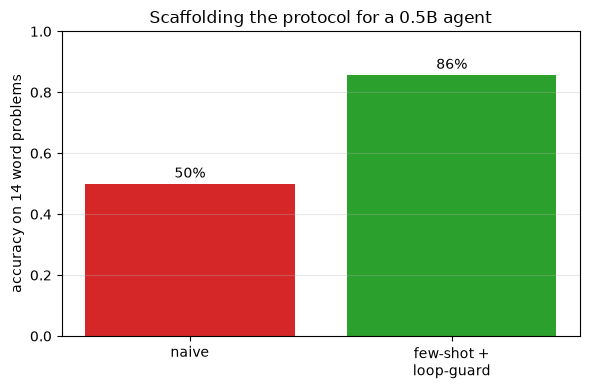

In [ ]:
final = Agent(lm, make_default_registry(), max_steps=6,
              sampling=SamplingConfig(max_new_tokens=128),
              few_shot=True, nudge_on_repeat=True)
final_records = evaluate_agent(final, GSM_TASKS)

na, fa = agent_summary(naive_records), agent_summary(final_records)
print("NAIVE :", {k: round(v, 3) for k, v in na.items()})
print("FINAL :", {k: round(v, 3) for k, v in fa.items()})

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["naive", "few-shot +\nloop-guard"]
vals = [na["accuracy"], fa["accuracy"]]
ax.bar(labels, vals, color=["tab:red", "tab:green"])
ax.set_ylim(0, 1)
ax.set_ylabel("accuracy on 14 word problems")
ax.set_title("Scaffolding the protocol for a 0.5B agent")
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 5. The payoff — tools vs chain-of-thought

The honest comparison against Notebook 06's chain-of-thought (no tools), on two task sets:

- **GSM-14** — easy arithmetic, multi-step *reasoning*. Hypothesis: the JSON+tool protocol is a *tax* on a 0.5B model, so plain CoT is competitive or better.
- **Hard-5** — trivial to set up, but the numbers are far beyond mental math (`4877 × 619`). Hypothesis: the calculator *dominates*.

Same model, greedy decoding, same answer-extraction/scoring for both — so the only variable is **reason-in-text vs call-a-tool**.

                      task set  CoT (no tools)  agent (calculator)
     GSM-14 (easy, multi-step)           0.929               0.857
Hard-5 (big-number arithmetic)           0.200               0.600

[h01]  4877 * 619 = 3018863
  CoT (mental math) -> 7.0
  agent (calculator) -> 3018863.0   (exact)


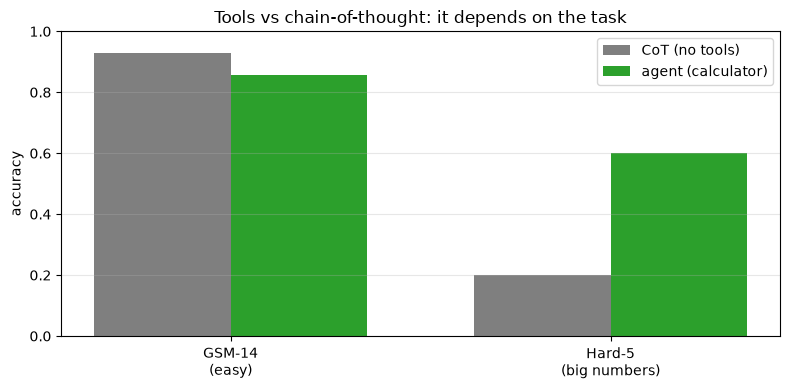

In [ ]:
cot_gsm = evaluate(lm, GSM_TASKS, cot_messages, "CoT", SamplingConfig(max_new_tokens=256))
cot_hard = evaluate(lm, HARD_ARITHMETIC_TASKS, cot_messages, "CoT", SamplingConfig(max_new_tokens=256))
agent_hard = evaluate_agent(final, HARD_ARITHMETIC_TASKS)

comparison = pd.DataFrame([
    {"task set": "GSM-14 (easy, multi-step)",
     "CoT (no tools)": cot_gsm.accuracy,
     "agent (calculator)": agent_summary(final_records)["accuracy"]},
    {"task set": "Hard-5 (big-number arithmetic)",
     "CoT (no tools)": cot_hard.accuracy,
     "agent (calculator)": agent_summary(agent_hard)["accuracy"]},
])
print(comparison.round(3).to_string(index=False))

# The single most telling example:
h01_cot = next(r for r in cot_hard.records if r.task_id == "h01")
h01_agent = next(r for r in agent_hard if r.task_id == "h01")
print(f"\n[h01]  4877 * 619 = {4877 * 619}")
print(f"  CoT (mental math) -> {h01_cot.pred}")
print(f"  agent (calculator) -> {h01_agent.pred}   (exact)")

x = np.arange(len(comparison))
w = 0.36
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w / 2, comparison["CoT (no tools)"], w, label="CoT (no tools)", color="tab:gray")
ax.bar(x + w / 2, comparison["agent (calculator)"], w, label="agent (calculator)", color="tab:green")
ax.set_xticks(x)
ax.set_xticklabels(["GSM-14\n(easy)", "Hard-5\n(big numbers)"])
ax.set_ylim(0, 1)
ax.set_ylabel("accuracy")
ax.set_title("Tools vs chain-of-thought: it depends on the task")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 6. The loop survives bad model output

An agent that crashes on the first malformed action is useless. The loop turns every failure into an *observation* and keeps going. We prove it deterministically with a **scripted fake model** (no LLM) — the same technique `tests/test_agent.py` uses to test the entire loop without a GPU. Three adversarial scripts: malformed JSON, a hallucinated tool name, and a model that never stops.

In [ ]:
class FakeModel:
    """Replays scripted generations so we can drive the loop deterministically."""
    def __init__(self, scripted):
        self.scripted, self.calls = list(scripted), 0

    def generate(self, messages, sampling=None):
        text = self.scripted[min(self.calls, len(self.scripted) - 1)]
        self.calls += 1
        return type("R", (), {"text": text, "new_tokens": 0})()


scenarios = {
    "malformed JSON, then recovers": [
        "Hmm, I think it's about 5, let me just say that.",
        '{"thought": "use the calculator", "tool": "calculator", "args": {"expression": "2 + 3"}}',
        '{"thought": "done", "tool": "final_answer", "args": {"answer": "5"}}',
    ],
    "hallucinated tool, then recovers": [
        '{"thought": "look it up", "tool": "wikipedia", "args": {"q": "5"}}',
        '{"thought": "that tool does not exist; calculate instead", "tool": "calculator", "args": {"expression": "2 + 3"}}',
        '{"thought": "done", "tool": "final_answer", "args": {"answer": "5"}}',
    ],
    "never terminates (hits max_steps)": [
        '{"thought": "again", "tool": "calculator", "args": {"expression": "2 + 3"}}',
    ],
}

for name, script in scenarios.items():
    res = Agent(FakeModel(script), make_default_registry(),
                max_steps=4, nudge_on_repeat=False).run("What is 2 + 3?")
    print(f"# {name}")
    print_trace(res)
    print()

# malformed JSON, then recovers
  step 1: [unparseable output] -> Error: respond with ONE JSON object containing the keys 'thought', 'tool', and 'args'.
  step 2: calculator({'expression': '2 + 3'})  ->  5
  step 3: final_answer({'answer': '5'})
  => answer='5'  success=True  steps=3  tokens=0

# hallucinated tool, then recovers
  step 1: wikipedia({'q': '5'})  ->  Error: unknown tool 'wikipedia'. Available tools: calculator, final_answer.
  step 2: calculator({'expression': '2 + 3'})  ->  5
  step 3: final_answer({'answer': '5'})
  => answer='5'  success=True  steps=3  tokens=0

# never terminates (hits max_steps)
  step 1: calculator({'expression': '2 + 3'})  ->  5
  step 2: calculator({'expression': '2 + 3'})  ->  5
  step 3: calculator({'expression': '2 + 3'})  ->  5
  step 4: calculator({'expression': '2 + 3'})  ->  5
  => answer=None  success=False  steps=4  tokens=0



## 7. What this means for the lab

- **Tools make arithmetic exact.** The agent solves `4877 × 619` precisely while CoT is off by orders of magnitude, and it fixes the exact arithmetic slip CoT made on the water-tank problem in Notebook 06. Where the model genuinely *can't* compute, a tool is transformative.
- **But the protocol is a tax.** Forcing a 0.5B model to emit JSON and call tools introduces failure modes it doesn't have when it just talks: looping, mis-planning, malformed output. On *easy* arithmetic, plain chain-of-thought matches or beats the agent. Capability and protocol-adherence are different axes — and small models are weak on the second.
- **Agent quality is an engineering loop, measured not assumed.** Few-shot scaffolding, loop-guards, and robust parsing each moved the number — and one "obvious" improvement (a longer worked example) made things *worse*. Always ablate.
- **The trace is the unit of debugging.** Every thought, tool call, and observation is recorded; you debug an agent by reading its trace, not its final answer.
- **Tools fix arithmetic, not planning.** The residual errors are wrong *expressions*, not wrong *computation* — the next frontier is better planning and verification, not a better calculator.

**Next — Notebook 08 (memory):** the scratchpad here is ephemeral **working memory**, rebuilt every task and discarded at `return`. We'll add *persistent* memory — store, retrieve, summarise, and let the agent decide what to keep across tasks — which is the lab's core research thread.

In [ ]:
summary = {
    "model": lm.model_id,
    "device": lm.device,
    "gsm_14": {
        "naive_agent": {k: round(v, 3) for k, v in agent_summary(naive_records).items()},
        "final_agent": {k: round(v, 3) for k, v in agent_summary(final_records).items()},
        "cot": {"accuracy": round(cot_gsm.accuracy, 3),
                "avg_new_tokens": round(cot_gsm.avg_new_tokens, 1)},
    },
    "hard_arithmetic_5": {
        "cot": {"accuracy": round(cot_hard.accuracy, 3)},
        "final_agent": {k: round(v, 3) for k, v in agent_summary(agent_hard).items()},
    },
}
path = config.RESULTS_DIR / "07_manual_tool_calling_agent.json"
path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("\nwrote", path)

{
  "model": "Qwen/Qwen2.5-0.5B-Instruct",
  "device": "mps",
  "gsm_14": {
    "naive_agent": {
      "accuracy": 0.5,
      "terminated": 0.857,
      "avg_steps": 3.357,
      "avg_tokens": 137.571
    },
    "final_agent": {
      "accuracy": 0.857,
      "terminated": 0.929,
      "avg_steps": 2.5,
      "avg_tokens": 133.214
    },
    "cot": {
      "accuracy": 0.929,
      "avg_new_tokens": 184.5
    }
  },
  "hard_arithmetic_5": {
    "cot": {
      "accuracy": 0.2
    },
    "final_agent": {
      "accuracy": 0.6,
      "terminated": 0.8,
      "avg_steps": 3.6,
      "avg_tokens": 173.8
    }
  }
}

wrote /Users/iali/workplace/projects/personal/ml-notes/docs/LLM/results/07_manual_tool_calling_agent.json
